# Fresnel Optics Notebook and Infrared Spectroscopy Simulations

## Unit conventions used 
- `theta_*_deg` → angle in **degrees**
- `wavenumber_cm_inv` → wavenumber in **cm⁻¹**
- `wavelength_cm` → wavelength in **cm**
- `wavelength_m` → wavelength in **m**
- `d_cm` / `d_m` → thickness in **cm** or **m**
- `n`, `k`, `r`, `t`, `R`, `T` → dimensionless



In [1]:
# 1. Imports and notebook configuration
%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import interact
#from mpl_toolkits.mplot3d import Axes3D  # optional 3D plotting


## 2. Data loading

This section loads optical constants from a spreadsheet.

Expected column names:
- `wave_numbers`
- `n0`, `n1`, `n2`
- `k0`, `k1`, `k2`

If your file is not found, update `DATA_PATH` below.

In [2]:
# 2.1 Data file path
# Replace this with the correct local path to your spreadsheet.
DATA_PATH = "2p00(8)_Fresnell.xlsx"


def load_optical_constants(path):
    """Load optical constants from an Excel spreadsheet.

    Parameters
    ----------
    path : str
        Path to the Excel file.

    Returns
    -------
    dict
        Dictionary containing numpy arrays with keys:
        wave_numbers, n0, n1, n2, k0, k1, k2
    """
    df = pd.read_excel(path)

    required_columns = [
        "wave_numbers",
        "n0", "n1", "n2",
        "k0", "k1", "k2",
    ]

    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    return {
        "wave_numbers": df["wave_numbers"].to_numpy(),
        "n0_array": df["n0"].to_numpy(),
        "n1_array": df["n1"].to_numpy(),
        "n2_array": df["n2"].to_numpy(),
        "k0_array": df["k0"].to_numpy(),
        "k1_array": df["k1"].to_numpy(),
        "k2_array": df["k2"].to_numpy(),
    }


# Uncomment to load the file once the path is correct:
data = load_optical_constants(DATA_PATH)
wave_numbers = data["wave_numbers"]
n0_array = data["n0_array"]
n1_array = data["n1_array"]
n2_array = data["n2_array"]
k0_array = data["k0_array"]
k1_array = data["k1_array"]
k2_array = data["k2_array"]

## 3. Math utilities

These keep the angle and wavelength handling explicit.


In [3]:
# 3.1 Physical constants
EPSILON_0 = 8.85e-12  # vacuum permittivity (F/m)

# 3.2 Angle helpers
def sin_deg(theta_deg):
    """Return sin(theta) for theta given in degrees."""
    return np.sin(theta_deg * np.pi / 180)


def cos_deg(theta_deg):
    """Return cos(theta) for theta given in degrees."""
    return np.cos(theta_deg * np.pi / 180)


def arcsin_deg(x):
    """Return arcsin(x) in degrees, including complex values."""
    return np.arcsin(x) * 180 / np.pi


# 3.3 Wavenumber / wavelength conversion helpers
def wavenumber_cm_inv_to_wavelength_cm(wavenumber_cm_inv):
    """Convert wavenumber in cm^-1 to wavelength in cm."""
    return 1.0 / wavenumber_cm_inv


def wavenumber_cm_inv_to_wavelength_m(wavenumber_cm_inv):
    """Convert wavenumber in cm^-1 to wavelength in m."""
    return 1.0 / (wavenumber_cm_inv * 100.0)


# 3.4 Optical index helpers
def complex_index(n, k):
    """Return the complex refractive index n + i k."""
    return n + 1j * k


def cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg):
    """Return cos(theta_t) from complex-index Snell's law."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
    return np.sqrt(1 - sin_theta_t**2)


def snells_law_theta_t_deg(ni, nt, ki, kt, theta_i_deg):
    """Return transmitted angle in degrees using complex-index Snell's law."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
    return arcsin_deg(sin_theta_t)

## 4. Single-interface Fresnel coefficients

This section contains the basic reflection and transmission coefficients
for s and p polarization, plus magnitude, reflectance, and transmittance.


In [4]:
def r_s(ni, nt, ki, kt, theta_i_deg, mu_i=EPSILON_0, mu_t=EPSILON_0):
    """s-polarized reflection coefficient at one interface."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    cos_theta_i = cos_deg(theta_i_deg)
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    numerator = (n_i / mu_i) * cos_theta_i - (n_t / mu_t) * cos_theta_t
    denominator = (n_i / mu_i) * cos_theta_i + (n_t / mu_t) * cos_theta_t
    return numerator / denominator


def t_s(ni, nt, ki, kt, theta_i_deg, mu_i=EPSILON_0, mu_t=EPSILON_0):
    """s-polarized transmission coefficient at one interface."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    cos_theta_i = cos_deg(theta_i_deg)
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    numerator = 2 * (n_i / mu_i) * cos_theta_i
    denominator = (n_i / mu_i) * cos_theta_i + (n_t / mu_t) * cos_theta_t
    return numerator / denominator


def r_p(ni, nt, ki, kt, theta_i_deg, mu_i=EPSILON_0, mu_t=EPSILON_0):
    """p-polarized reflection coefficient at one interface."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    cos_theta_i = cos_deg(theta_i_deg)
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    numerator = -(n_t / mu_t) * cos_theta_i + (n_i / mu_i) * cos_theta_t
    denominator = (n_t / mu_t) * cos_theta_i + (n_i / mu_i) * cos_theta_t
    return numerator / denominator


def t_p(ni, nt, ki, kt, theta_i_deg, mu_i=EPSILON_0, mu_t=EPSILON_0):
    """p-polarized transmission coefficient at one interface."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    cos_theta_i = cos_deg(theta_i_deg)
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    numerator = 2 * (n_i / mu_i) * cos_theta_i
    denominator = (n_t / mu_t) * cos_theta_i + (n_i / mu_i) * cos_theta_t
    return numerator / denominator


# Magnitudes
def mag_r_s(*args, **kwargs):
    return np.abs(r_s(*args, **kwargs))


def mag_t_s(*args, **kwargs):
    return np.abs(t_s(*args, **kwargs))


def mag_r_p(*args, **kwargs):
    return np.abs(r_p(*args, **kwargs))


def mag_t_p(*args, **kwargs):
    return np.abs(t_p(*args, **kwargs))


# Power coefficients
def Rperp(ni, nt, ki, kt, theta_i_deg):
    """Reflectance for s polarization: |r_s|^2."""
    r = r_s(ni, nt, ki, kt, theta_i_deg)
    return r * np.conjugate(r)


def Rpara(ni, nt, ki, kt, theta_i_deg):
    """Reflectance for p polarization: |r_p|^2."""
    r = r_p(ni, nt, ki, kt, theta_i_deg)
    return r * np.conjugate(r)


def Tperp(ni, nt, ki, kt, theta_i_deg):
    """Transmittance for s polarization."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    t = t_s(ni, nt, ki, kt, theta_i_deg)
    return ((n_t * cos_theta_t) / (n_i * cos_deg(theta_i_deg))) * t * np.conjugate(t)


def Tpara(ni, nt, ki, kt, theta_i_deg):
    """Transmittance for p polarization."""
    n_i = complex_index(ni, ki)
    n_t = complex_index(nt, kt)
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    t = t_p(ni, nt, ki, kt, theta_i_deg)
    return ((n_t * cos_theta_t) / (n_i * cos_deg(theta_i_deg))) * t * np.conjugate(t)

## 5. Two-interface coefficients from explicit formulas

These functions compute the total reflection and transmission amplitudes for
a three-medium system: medium 0 → film 1 → medium 2.

### Unit note
`d` and `wavelength` must be in the **same length unit**.


In [5]:
def film_phase_factor(n1, k1, d, theta_1_deg, wavelength):
    """Single-pass thin-film phase factor exp(i*beta).

    Parameters
    ----------
    n1, k1 : float
        Optical constants of the film.
    d : float
        Film thickness (same unit as `wavelength`).
    theta_1_deg : float or array
        Angle in film, in degrees.
    wavelength : float
        Wavelength in the same unit as `d`.
    """
    n1_complex = complex_index(n1, k1)
    return np.exp(1j * 2 * np.pi * d * n1_complex * cos_deg(theta_1_deg) / wavelength)


def t_s_total(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)

    t01 = t_s(n0, n1, k0, k1, theta_0_deg)
    t12 = t_s(n1, n2, k1, k2, theta_1_deg)
    r10 = r_s(n1, n0, k1, k0, theta_1_deg)
    r12 = r_s(n1, n2, k1, k2, theta_1_deg)
    phase = film_phase_factor(n1, k1, d, theta_1_deg, wavelength)

    return (t01 * phase * t12) / (1 - r10 * phase**2 * r12)


def r_s_total(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)

    r01 = r_s(n0, n1, k0, k1, theta_0_deg)
    r10 = r_s(n1, n0, k1, k0, theta_1_deg)
    r12 = r_s(n1, n2, k1, k2, theta_1_deg)
    t01 = t_s(n0, n1, k0, k1, theta_0_deg)
    t12 = t_s(n1, n2, k1, k2, theta_1_deg)
    phase = film_phase_factor(n1, k1, d, theta_1_deg, wavelength)

    return r01 + (phase**2 * t01 * r12 * t12) / (1 - r10 * r12 * phase**2)


def t_p_total(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)

    t01 = t_p(n0, n1, k0, k1, theta_0_deg)
    t12 = t_p(n1, n2, k1, k2, theta_1_deg)
    r10 = r_p(n1, n0, k1, k0, theta_1_deg)
    r12 = r_p(n1, n2, k1, k2, theta_1_deg)
    phase = film_phase_factor(n1, k1, d, theta_1_deg, wavelength)

    return (t01 * phase * t12) / (1 - r10 * phase**2 * r12)


def r_p_total(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)

    r01 = r_p(n0, n1, k0, k1, theta_0_deg)
    r10 = r_p(n1, n0, k1, k0, theta_1_deg)
    r12 = r_p(n1, n2, k1, k2, theta_1_deg)
    t01 = t_p(n0, n1, k0, k1, theta_0_deg)
    t12 = t_p(n1, n2, k1, k2, theta_1_deg)
    phase = film_phase_factor(n1, k1, d, theta_1_deg, wavelength)

    return r01 + (phase**2 * t01 * r12 * t12) / (1 - r10 * r12 * phase**2)


def mag_r_s_total(*args, **kwargs):
    return np.abs(r_s_total(*args, **kwargs))


def mag_t_s_total(*args, **kwargs):
    return np.abs(t_s_total(*args, **kwargs))


def mag_r_p_total(*args, **kwargs):
    return np.abs(r_p_total(*args, **kwargs))


def mag_t_p_total(*args, **kwargs):
    return np.abs(t_p_total(*args, **kwargs))


6. Transfer-matrix method

This is the matrix-based version of the same three-medium system. It is slower but can be extended to any arbitrary number of layers. 

In [7]:
def D_p(ni, nt, ki, kt, theta_i_deg, mu_i=EPSILON_0, mu_t=EPSILON_0):
    """Interface matrix for p polarization."""
    rp = r_p(ni, nt, ki, kt, theta_i_deg, mu_i=mu_i, mu_t=mu_t)
    tp = t_p(ni, nt, ki, kt, theta_i_deg, mu_i=mu_i, mu_t=mu_t)
    return (1 / tp) * np.array([[1, rp], [rp, 1]])


def D_s(ni, nt, ki, kt, theta_i_deg, mu_i=EPSILON_0, mu_t=EPSILON_0):
    """Interface matrix for s polarization."""
    rs = r_s(ni, nt, ki, kt, theta_i_deg, mu_i=mu_i, mu_t=mu_t)
    ts = t_s(ni, nt, ki, kt, theta_i_deg, mu_i=mu_i, mu_t=mu_t)
    return (1 / ts) * np.array([[1, rs], [rs, 1]])


def P(ni, nt, ki, kt, theta_i_deg, d, wavelength):
    """Propagation matrix through a layer.

    `d` and `wavelength` must use the same length unit.
    """
    cos_theta_t = cos_theta_transmitted(ni, nt, ki, kt, theta_i_deg)
    n_t = complex_index(nt, kt)
    phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
    return np.array([
        [np.exp(phase), 0],
        [0, np.exp(-phase)],
    ])


def t_s_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)
    M = D_s(n0, n1, k0, k1, theta_0_deg) @ P(n0, n1, k0, k1, theta_0_deg, d, wavelength) @ D_s(n1, n2, k1, k2, theta_1_deg)
    return 1 / M[0, 0]


def t_p_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)
    M = D_p(n0, n1, k0, k1, theta_0_deg) @ P(n0, n1, k0, k1, theta_0_deg, d, wavelength) @ D_p(n1, n2, k1, k2, theta_1_deg)
    return 1 / M[0, 0]


def r_s_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)
    M = D_s(n0, n1, k0, k1, theta_0_deg) @ P(n0, n1, k0, k1, theta_0_deg, d, wavelength) @ D_s(n1, n2, k1, k2, theta_1_deg)
    return M[1, 0] / M[0, 0]


def r_p_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg, wavelength):
    theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, theta_0_deg)
    M = D_p(n0, n1, k0, k1, theta_0_deg) @ P(n0, n1, k0, k1, theta_0_deg, d, wavelength) @ D_p(n1, n2, k1, k2, theta_1_deg)
    return M[1, 0] / M[0, 0]


## 7. Interactive plots for a single interface

These produce interactive plots of theoretical fresnell data. 


In [8]:
def plot_single_interface_amplitudes(func1, func2, func3, func4):
    """Interactive plot of four single-interface amplitude functions vs incident angle."""
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)

    theta_i_deg = np.linspace(0.1, 89.9, 10000)

    line1, = ax.plot([], [], 'r--')
    line2, = ax.plot([], [], 'b--')
    line3, = ax.plot([], [], 'r-')
    line4, = ax.plot([], [], 'b-')

    ax.set_xlim((0, 90))
    ax.set_ylim((-1, 1))
    ax.axhline(0, linewidth=0.75, color='k')
    ax.set_xlabel(r'Incident angle $\theta_i$ (deg)')
    ax.set_ylabel('Amplitude coefficient')
    ax.legend([r'$r_s$', r'$t_s$', r'$r_p$', r'$t_p$'])

    def plot(ni=1.0, nt=1.5, ki=0.0, kt=0.0):
        out1 = func1(ni, nt, ki, kt, theta_i_deg)
        out2 = func2(ni, nt, ki, kt, theta_i_deg)
        out3 = func3(ni, nt, ki, kt, theta_i_deg)
        out4 = func4(ni, nt, ki, kt, theta_i_deg)

        line1.set_data(theta_i_deg, out1)
        line2.set_data(theta_i_deg, out2)
        line3.set_data(theta_i_deg, out3)
        line4.set_data(theta_i_deg, out4)
        plt.draw()

    interact(plot, ni=(0, 5, 0.1), nt=(0, 5, 0.1), ki=(0, 5, 0.1), kt=(0, 5, 0.1))


def plot_single_interface_power(func1, func2, func3, func4):
    """Interactive plot of reflectance/transmittance vs incident angle."""
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)

    theta_i_deg = np.linspace(0.1, 89.9, 10000)

    line1, = ax.plot([], [], 'r--')
    line2, = ax.plot([], [], 'b--')
    line3, = ax.plot([], [], 'r-')
    line4, = ax.plot([], [], 'b-')

    ax.set_xlim((0, 90))
    ax.set_ylim((0, 1))
    ax.axhline(0, linewidth=0.75, color='k')
    ax.set_xlabel(r'Incident angle $\theta_i$ (deg)')
    ax.set_ylabel('Reflectance / transmittance')
    ax.legend([r'$R_s$', r'$T_s$', r'$R_p$', r'$T_p$'])

    def plot(ni=1.0, nt=1.5, ki=0.0, kt=0.0):
        out1 = func1(ni, nt, ki, kt, theta_i_deg)
        out2 = func2(ni, nt, ki, kt, theta_i_deg)
        out3 = func3(ni, nt, ki, kt, theta_i_deg)
        out4 = func4(ni, nt, ki, kt, theta_i_deg)

        line1.set_data(theta_i_deg, out1)
        line2.set_data(theta_i_deg, out2)
        line3.set_data(theta_i_deg, out3)
        line4.set_data(theta_i_deg, out4)
        plt.draw()

    interact(plot, ni=(0, 5, 0.01), nt=(0, 5, 0.01), ki=(0, 5, 0.01), kt=(0, 5, 0.01))

## 8. Phase shift and evanescent-wave plots
These produce interactive plots of theoretical evanescent wave behavior and phase shifts caused bycrossing interfaces. 

In [9]:
def phase_shift(z):
    """Return phase angle of a complex quantity in radians."""
    return np.angle(z)


def phase_plot(func1, func2, func3, func4):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)

    theta_i_deg = np.linspace(0.1, 89.9, 10000)

    line1, = ax.plot([], [], 'r--')
    line2, = ax.plot([], [], 'b--')
    line3, = ax.plot([], [], 'r-')
    line4, = ax.plot([], [], 'b-')

    ax.set_xlim((0, 90))
    ax.set_ylim((-np.pi, np.pi))
    ax.axhline(0, linewidth=0.75, color='k')
    ax.set_xlabel(r'Incident angle $\theta_i$ (deg)')
    ax.set_ylabel('Phase shift (rad)')
    ax.legend([r'phase($r_s$)', r'phase($t_s$)', r'phase($r_p$)', r'phase($t_p$)'])

    def plot(ni=1.0, nt=1.5, ki=0.0, kt=0.0):
        out1 = phase_shift(func1(ni, nt, ki, kt, theta_i_deg))
        out2 = phase_shift(func2(ni, nt, ki, kt, theta_i_deg))
        out3 = phase_shift(func3(ni, nt, ki, kt, theta_i_deg))
        out4 = phase_shift(func4(ni, nt, ki, kt, theta_i_deg))

        line1.set_data(theta_i_deg, out1)
        line2.set_data(theta_i_deg, out2)
        line3.set_data(theta_i_deg, out3)
        line4.set_data(theta_i_deg, out4)
        plt.draw()

    interact(plot, ni=(0, 5, 0.01), nt=(0, 5, 0.01), ki=(0, 5, 0.01), kt=(0, 5, 0.01))


def ReE_t(ni, nt, y, x, theta_i_deg, lamb_0=800, E_0t=1):
    """Real transmitted evanescent field amplitude.

    Notes
    -----
    This function preserves the original form from the notebook.
    The wavelength parameter `lamb_0` should be in the same unit as `x` and `y`.
    """
    decay_term = np.exp(
        (-2 * np.pi * nt / lamb_0) * (((ni**2) / (nt**2) * (sin_deg(theta_i_deg))**2 - 1) ** 0.5) * y
    )
    oscillation = np.cos((2 * np.pi / lamb_0) * x * sin_deg(theta_i_deg))
    return E_0t * decay_term * oscillation


def evanescent_decay_plot(func):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)

    line1, = ax.plot([], [], 'r-')
    ax.set_xlim((0, 1000))
    ax.set_ylim((-1, 1))
    ax.axhline(0, linewidth=0.75, color='k')
    ax.set_xlabel('y')
    ax.set_ylabel('Transmitted field amplitude')
    ax.legend([r'Re($E_t$)'])

    def plot(ni=1.5, nt=1.0, x=0.0, theta_i_deg=43.0):
        y = np.linspace(0.1, 1000, 10000)
        out = func(ni, nt, y, x, theta_i_deg)
        line1.set_data(y, out)
        plt.draw()

    interact(plot, ni=(0, 5, 0.1), nt=(0, 5, 0.1), x=(0, 1000, 0.1), theta_i_deg=(43, 89.9, 0.1))


## 9. Interactive plots for total thin-film coefficients


In [10]:
def matrix_r_p_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength):
    return np.array([np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, theta_deg, wavelength)) for theta_deg in theta_0_deg_array])


def matrix_r_s_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength):
    return np.array([np.abs(r_s_tot(n0, n1, n2, k0, k1, k2, d, theta_deg, wavelength)) for theta_deg in theta_0_deg_array])


def matrix_t_p_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength):
    return np.array([np.abs(t_p_tot(n0, n1, n2, k0, k1, k2, d, theta_deg, wavelength)) for theta_deg in theta_0_deg_array])


def matrix_t_s_tot(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength):
    return np.array([np.abs(t_s_tot(n0, n1, n2, k0, k1, k2, d, theta_deg, wavelength)) for theta_deg in theta_0_deg_array])


def total_fresnel_coeff_plot(func1, func2, func3, func4):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)

    theta_0_deg_array = np.linspace(0.1, 89.9, 10000)

    line1, = ax.plot([], [], 'r--')
    line2, = ax.plot([], [], 'b--')
    line3, = ax.plot([], [], 'r-')
    line4, = ax.plot([], [], 'b-')

    ax.set_xlim((0, 90))
    ax.set_ylim((-1, 1))
    ax.axhline(0, linewidth=0.75, color='k')
    ax.set_xlabel(r'Incident angle $\theta_i$ (deg)')
    ax.set_ylabel('Amplitude coefficient')
    ax.legend([r'$|r_s^{tot}|$', r'$|t_s^{tot}|$', r'$|r_p^{tot}|$', r'$|t_p^{tot}|$'])

    def plot(n0=1.0, n1=1.4, n2=1.5, k0=0.0, k1=0.0, k2=0.0, d=1.0, wavelength=4.0):
        out1 = func1(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength)
        out2 = func2(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength)
        out3 = func3(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength)
        out4 = func4(n0, n1, n2, k0, k1, k2, d, theta_0_deg_array, wavelength)

        line1.set_data(theta_0_deg_array, out1)
        line2.set_data(theta_0_deg_array, out2)
        line3.set_data(theta_0_deg_array, out3)
        line4.set_data(theta_0_deg_array, out4)
        plt.draw()

    interact(
        plot,
        n0=(0, 5, 0.1),
        n1=(0, 5, 0.1),
        n2=(0, 5, 0.1),
        k0=(0, 5, 0.1),
        k1=(0, 5, 0.1),
        k2=(0, 5, 0.1),
        d=(0, 5, 0.1),
        wavelength=(0.1, 5, 0.1),
    )


## 10. Spectral plots

This section reproduces the original spectrum workflow, but with:
- clearer mode descriptions
- consistent wavelength conversion from wavenumber
- clearer variable names
- one helper that computes total `r` and `t` for each spectral point

### Modes
- `'0'`: plot `n0`, `k0`
- `'1'`: plot `n1`, `k1`
- `'2'`: plot `n2`, `k2`
- `'3'`: real parts of total `r`, `t`
- `'3.5'`: magnitudes of total `r`, `t`
- `'4'`: reflectance `R = |r|^2`
- `'5'`: real and imaginary parts of `r^2`
- `'6'`: absorptance `a = 1 - R` (no transmission case)
- `'7'`: absorbance `A = log10(1 / a)` (no transmission case)
- `'8'`: transmittance `T`
- `'9'`: absorbance with both reflection and transmission
- `'10'`: phase of `r`


In [42]:
def Fresnellbkg(polarization, i):
    """Background single-interface coefficient between medium 0 and 2.

    Not currently being used but may be helpful for future ratioing/reference.
    """
    n0, n2 = n0_array[i], n2_array[i]
    k0, k2 = k0_array[i], k2_array[i]

    if polarization == 'p':
        return r_p(n0, n2, k0, k2, 80), t_p(n0, n2, k0, k2, 80)
    return r_s(n0, n2, k0, k2, 80), t_s(n0, n2, k0, k2, 80)


def spectral_total_rt(i, d_cm, theta_0_deg, polarization):
    """Compute total r and t for one spectral index.

    Notes
    -----
    The film thickness `d_cm` is in cm.
    The wavelength is computed in cm from the input wavenumber.
    """
    n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
    k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]

    wavenumber_cm_inv = wave_numbers[i]
    wavelength_cm = wavenumber_cm_inv_to_wavelength_cm(wavenumber_cm_inv)

    if polarization == 'p':
        return r_p_tot(n0, n1, n2, k0, k1, k2, d_cm, theta_0_deg, wavelength_cm), t_p_tot(n0, n1, n2, k0, k1, k2, d_cm, theta_0_deg, wavelength_cm)
    return r_s_tot(n0, n1, n2, k0, k1, k2, d_cm, theta_0_deg, wavelength_cm), t_s_tot(n0, n1, n2, k0, k1, k2, d_cm, theta_0_deg, wavelength_cm)


def Spectraplot(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d, th0, mode='0', polarization='p'):
    """Plot optical constants or thin-film spectral quantities.

    Parameters
    ----------
    wave_numbers : array
        Wavenumber axis in cm^-1.
    d : float
        Film thickness in cm.
    th0 : float
        Incident angle in degrees.
    mode : str
        Selects which quantity to plot.
    polarization : {'s', 'p'}
        Polarization for total-coefficient calculations.
    """
    plt.figure(figsize=(8, 5))
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.gca().invert_xaxis()

    if mode == '0':
        plt.plot(wave_numbers, n0_array, label='n0')
        plt.plot(wave_numbers, k0_array, label='k0')
        plt.ylabel('Optical constants')

    elif mode == '1':
        plt.plot(wave_numbers, n1_array, label='n1')
        plt.plot(wave_numbers, k1_array, label='k1')
        plt.ylabel('Optical constants')

    elif mode == '2':
        plt.plot(wave_numbers, n2_array, label='n2')
        plt.plot(wave_numbers, k2_array, label='k2')
        plt.ylabel('Optical constants')

    elif mode == '3':
        r_list, t_list = [], []
        for i in range(len(wave_numbers)):
            r, t = spectral_total_rt(i, d, th0, polarization)
            r_list.append(np.real(r))
            t_list.append(np.real(t))
        plt.plot(wave_numbers, r_list, label='Re(r_total)')
        plt.plot(wave_numbers, t_list, label='Re(t_total)')
        plt.ylabel('Real part of coefficients')

    elif mode == '3.5':
        r_list, t_list = [], []
        for i in range(len(wave_numbers)):
            r, t = spectral_total_rt(i, d, th0, polarization)
            r_list.append(np.abs(r))
            t_list.append(np.abs(t))
        plt.plot(wave_numbers, r_list, label='|r_total|')
        plt.plot(wave_numbers, t_list, label='|t_total|')
        plt.ylabel('Magnitude of coefficients')

    elif mode == '4':
        reflectance = []
        for i in range(len(wave_numbers)):
            r, _ = spectral_total_rt(i, d, th0, polarization)
            reflectance.append(np.abs(r) ** 2)
        plt.plot(wave_numbers, reflectance, label='R')
        plt.ylabel(r'Reflectance $|r|^2$')

    elif mode == '5':
        real_r2, imag_r2 = [], []
        for i in range(len(wave_numbers)):
            r, _ = spectral_total_rt(i, d, th0, polarization)
            real_r2.append(np.real(r ** 2))
            imag_r2.append(np.imag(r ** 2))
        plt.plot(wave_numbers, real_r2, label='Re(r²)')
        plt.plot(wave_numbers, imag_r2, label='Im(r²)')
        plt.ylabel(r'Real / imaginary parts of $r^2$')

    elif mode == '6':
        absorptance = []
        for i in range(len(wave_numbers)):
            r, _ = spectral_total_rt(i, d, th0, polarization)
            R = np.abs(r) ** 2
            a = 1 - R
            absorptance.append(a)
        plt.plot(wave_numbers, absorptance, label='a')
        plt.ylabel('Absorptance')

    elif mode == '7':
        absorbance = []
        for i in range(len(wave_numbers)):
            r, _ = spectral_total_rt(i, d, th0, polarization)
            R = np.abs(r) ** 2
            a = 1 - R
            A = np.log10(1 / a) - 0.995
            absorbance.append(A)
        x = wave_numbers
        y = absorbance
        plt.plot(x, y, label='A') 
        plt.ylabel('Absorbance')   
        df = pd.DataFrame({
            'wave_number': x,
            'absorbance': y
        })
       
    elif mode == '8':
        transmittance = []
        for i in range(len(wave_numbers)):
            n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
            k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]  # corrected from original typo

            cos_theta_0 = cos_deg(th0)
            theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, th0)
            theta_2_deg = snells_law_theta_t_deg(n1, n2, k1, k2, theta_1_deg)
            cos_theta_2 = cos_deg(theta_2_deg)

            _, t = spectral_total_rt(i, d, th0, polarization)
            T = np.real((n2 * cos_theta_2) / (n0 * cos_theta_0)) * np.abs(t) ** 2
            transmittance.append(T)

        plt.plot(wave_numbers, transmittance, label='T')
        plt.ylabel('Transmittance')

    elif mode == '9':
        absorbance = []
        for i in range(len(wave_numbers)):
            n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
            k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]  # corrected from original typo

            cos_theta_0 = cos_deg(th0)
            theta_1_deg = snells_law_theta_t_deg(n0, n1, k0, k1, th0)
            theta_2_deg = snells_law_theta_t_deg(n1, n2, k1, k2, theta_1_deg)
            cos_theta_2 = cos_deg(theta_2_deg)

            r, t = spectral_total_rt(i, d, th0, polarization)
            T = np.real((n2 * cos_theta_2) / (n0 * cos_theta_0)) * np.abs(t) ** 2
            R = np.abs(r) ** 2
            a = 1 - R - T
            A = np.log10(1 / a)
            absorbance.append(A)

        plt.plot(wave_numbers, absorbance, label='A')
        plt.ylabel('Absorbance')

    elif mode == '10':
        phase = []
        for i in range(len(wave_numbers)):
            r, _ = spectral_total_rt(i, d, th0, polarization)
            phase.append(np.angle(r))
        plt.plot(wave_numbers, phase, label='arg(r)')
        plt.ylabel('Phase of r (rad)')

    else:
        plt.text(0.5, 0.5, f"Unsupported mode: {mode}", ha='center')

    plt.title('Spectral plot')
    plt.legend()
    plt.grid(True)
    plt.xlim(2000, 800)
    plt.show()
    return df

## 11.  3D plot


In [43]:
def plot_3D(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d, th0, mode='7', polarization='p', view='xy'):
    """Optional 3D visualization preserved from the original notebook."""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    if mode == '0':
        ax.set_ylabel('n1')
        ax.set_zlabel('k1')
        ax.set_title('Complex refractive index')
        ax.plot(wave_numbers, n1_array, k1_array, label='Complex refractive index')

    elif mode == '1':
        r_real_list, r_imag_list = [], []
        for i in range(len(wave_numbers)):
            r, _ = spectral_total_rt(i, d, th0, polarization)
            r_real_list.append(np.real(r))
            r_imag_list.append(np.imag(r))

        ax.set_ylabel('Re(r)')
        ax.set_zlabel('Im(r)')
        ax.set_title('Complex reflection coefficient')
        ax.plot(wave_numbers, r_real_list, r_imag_list, label='Complex r')

    else:
        ax.text(0.5, 0.5, 0.5, f"Unsupported mode: {mode}", ha='center')

    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.legend()
    plt.show()


## 12. Example calls

Uncomment the cells you want to run.

Before running the spectral plots, make sure the data-loading cell has been run successfully.


In [44]:
# Example 1: single-interface amplitude coefficients
#plot_single_interface_amplitudes(r_s, t_s, r_p, t_p)
# plot_single_interface_amplitudes(mag_r_s, mag_t_s, mag_r_p, mag_t_p)

# Example 2: single-interface power coefficients
# plot_single_interface_power(Rperp, Tperp, Rpara, Tpara)

# Example 3: phase plot
# phase_plot(r_s, t_s, r_p, t_p)

# Example 4: evanescent field decay
# evanescent_decay_plot(ReE_t)

# Example 5: total thin-film coefficients from explicit formulas
# total_fresnel_coeff_plot(mag_r_s_total, mag_t_s_total, mag_r_p_total, mag_t_p_total)

# Example 6: total thin-film coefficients from the matrix method
# total_fresnel_coeff_plot(matrix_r_s_tot, matrix_t_s_tot, matrix_r_p_tot, matrix_t_p_tot)

# Example 7: spectral plot
# Spectraplot(
#     wave_numbers,
#     n0_array,
#     n1_array,
#     n2_array,
#     k0_array,
#     k1_array,
#     k2_array,
#     d=1.005e-6,      # cm
#     th0=85,          # degrees
#     mode='7',
#     polarization='p',
# )

# Example 8: 3D plot
# plot_3D(
#     wave_numbers,
#     n0_array,
#     n1_array,
#     n2_array,
#     k0_array,
#     k1_array,
#     k2_array,
#     d=1.005e-6,      # cm
#     th0=85,
#     mode='1',
#     polarization='p',
# )


Enter excel workbook name:  Herguedas-SiOx-interpolated_2
Enter output workbook name:  testing1


Processing sheet: 1.25


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


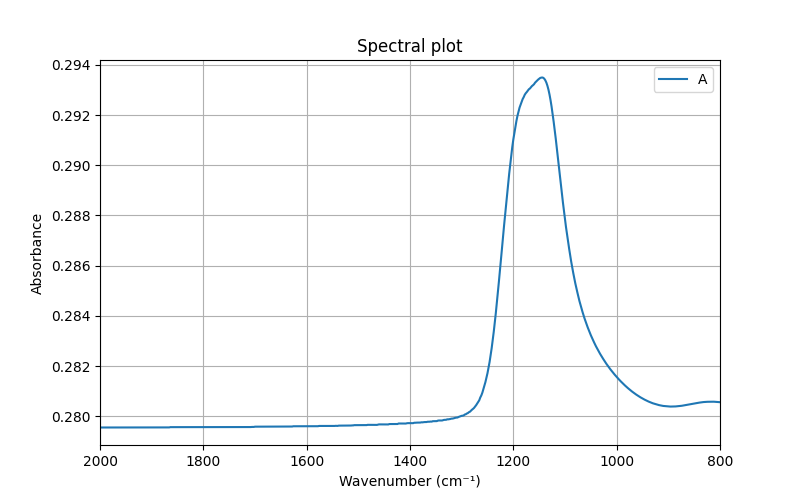

Processing sheet: 1.375


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


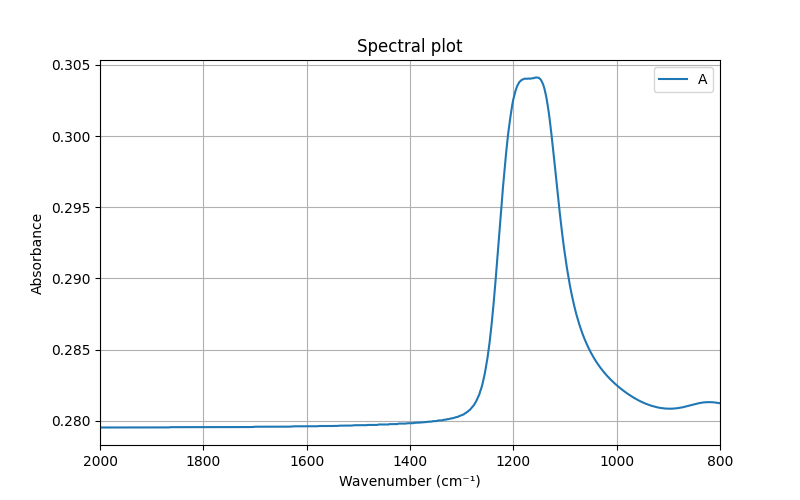

Processing sheet: 1.40


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


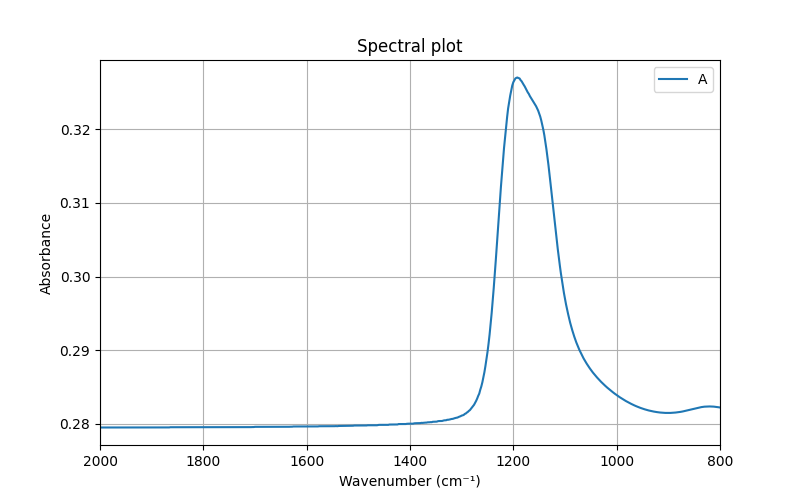

Processing sheet: 1.60


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


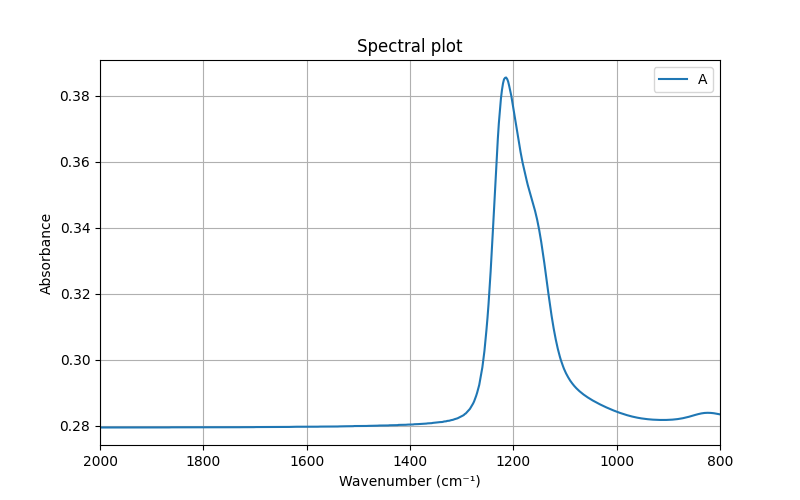

Processing sheet: 1.675


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


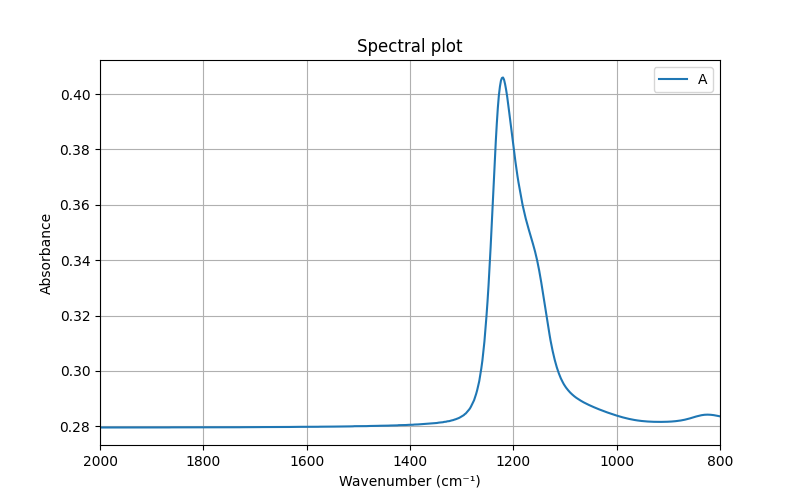

Processing sheet: 1.775


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


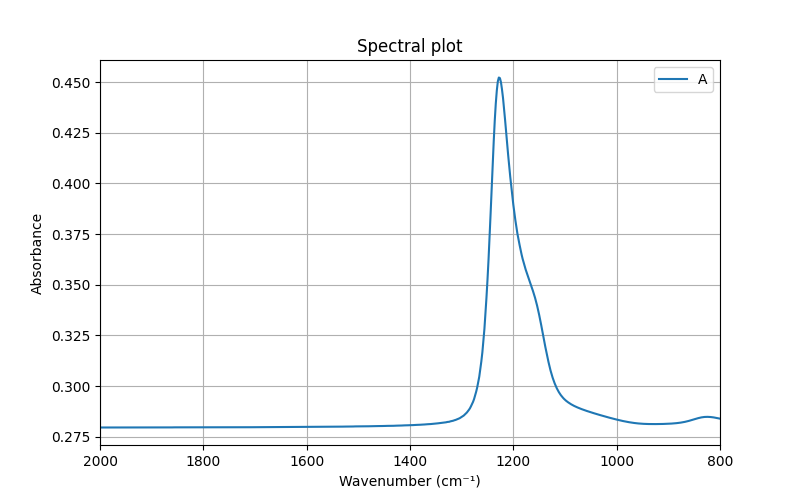

Processing sheet: 1.95


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


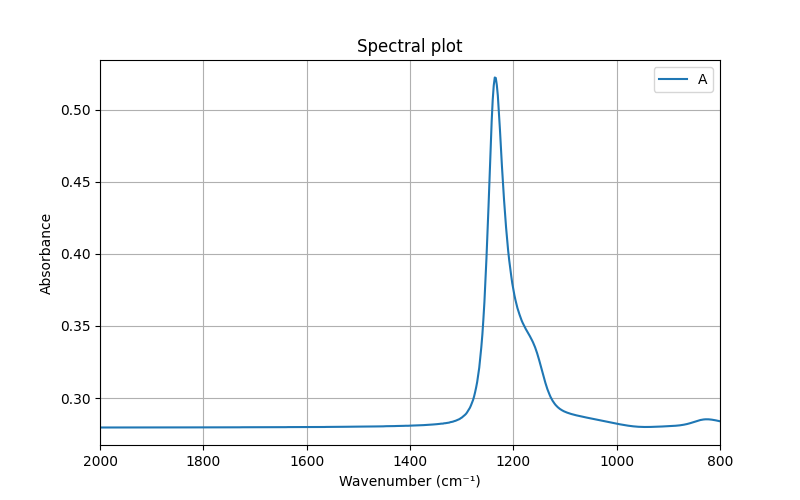

Processing sheet: 2.00


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


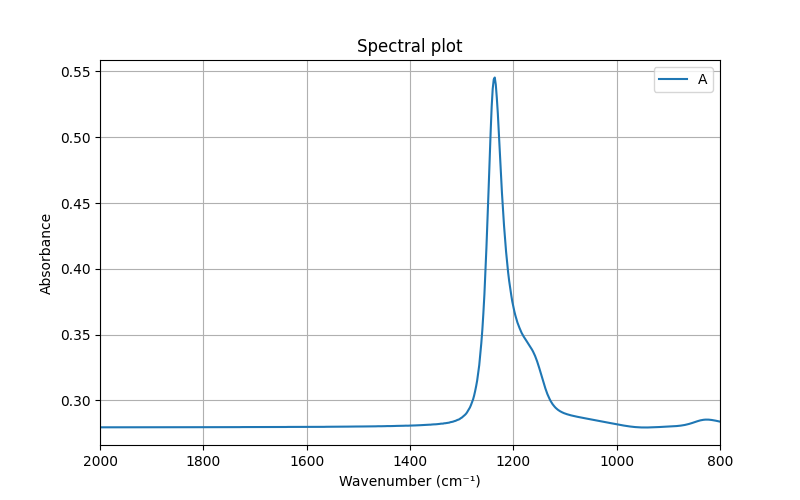

Processing sheet: 2.00 (2)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


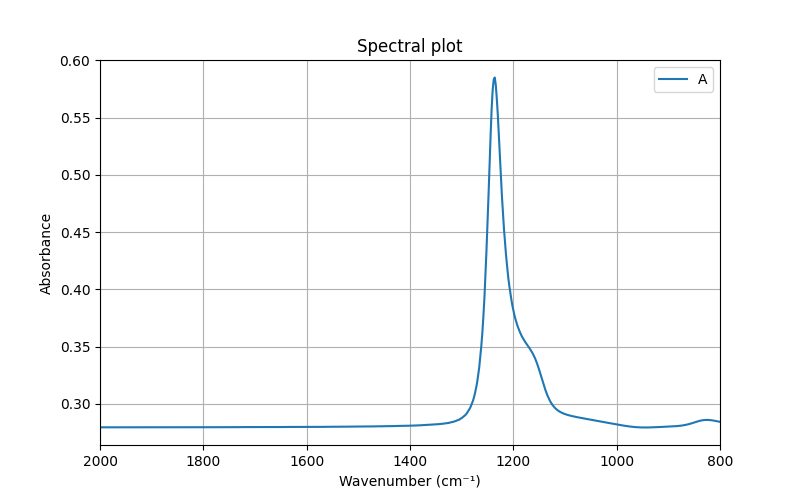

Processing sheet: 2.00 (3)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


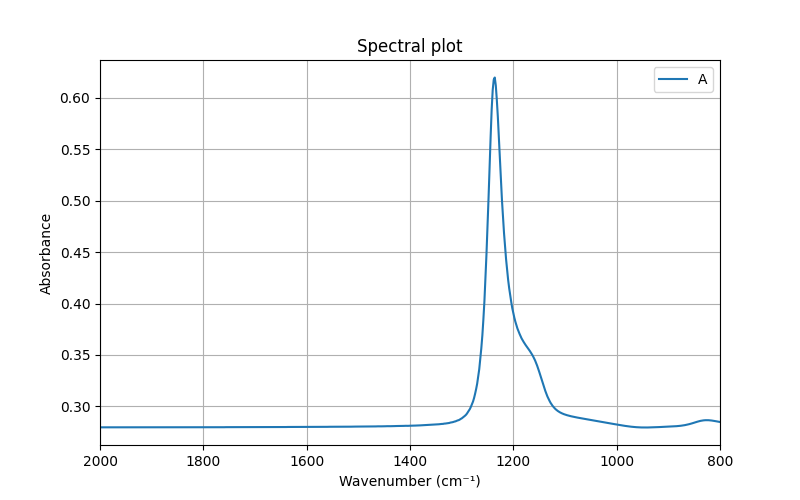

Processing sheet: 2.00 (4)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


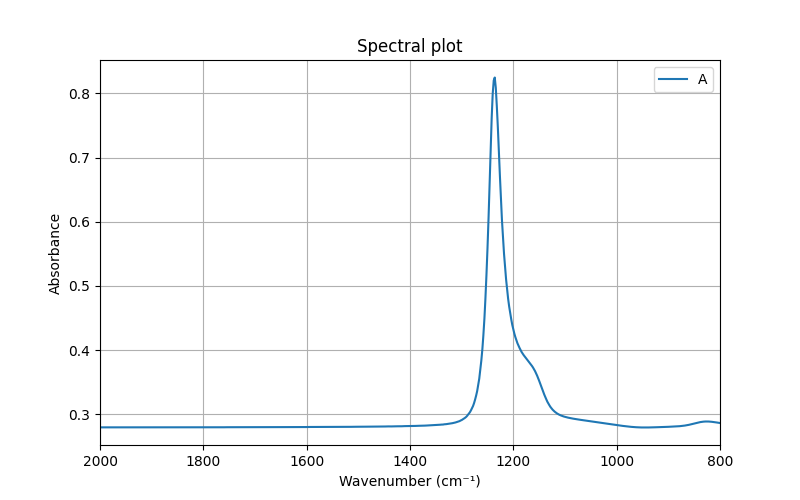

Processing sheet: 2.00 (5)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


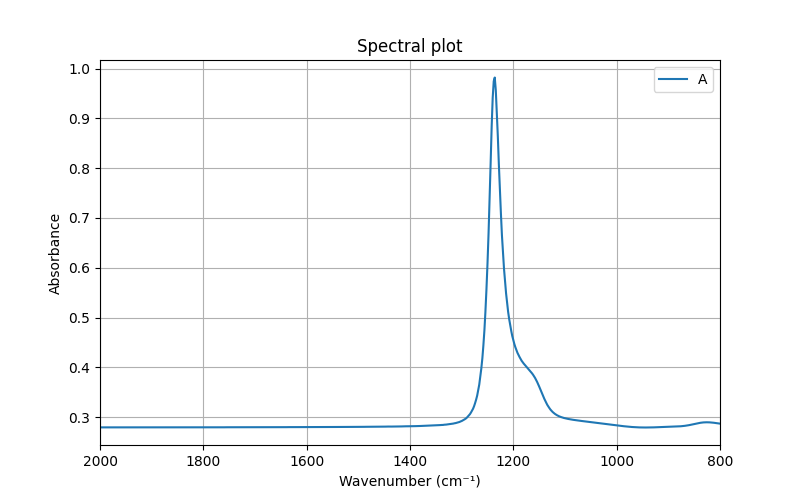

Processing sheet: 2.00 (6)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


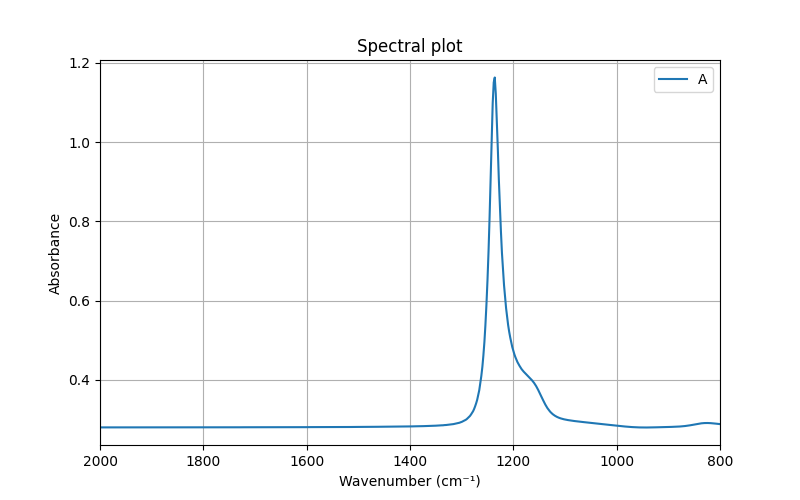

Processing sheet: 2.00 (7)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


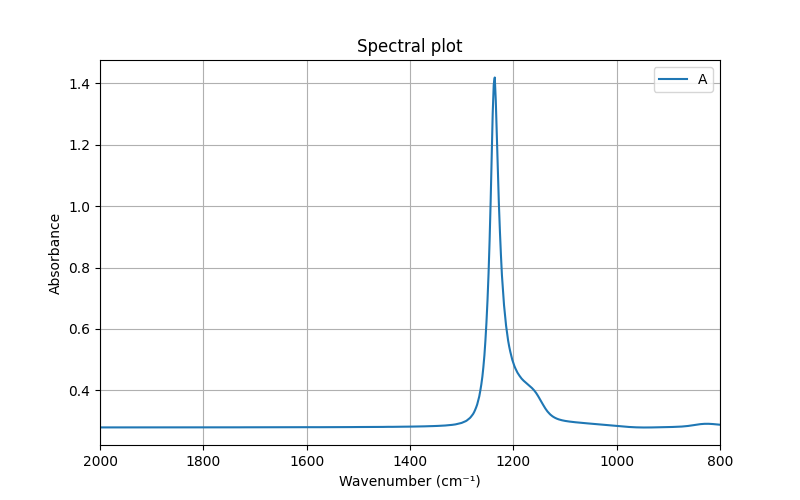

Processing sheet: 2.00 (8)


/tmp/ipykernel_440116/927119675.py:122: RuntimeWarning: invalid value encountered in log10
  A = np.log10(1 / a) - 0.995
/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


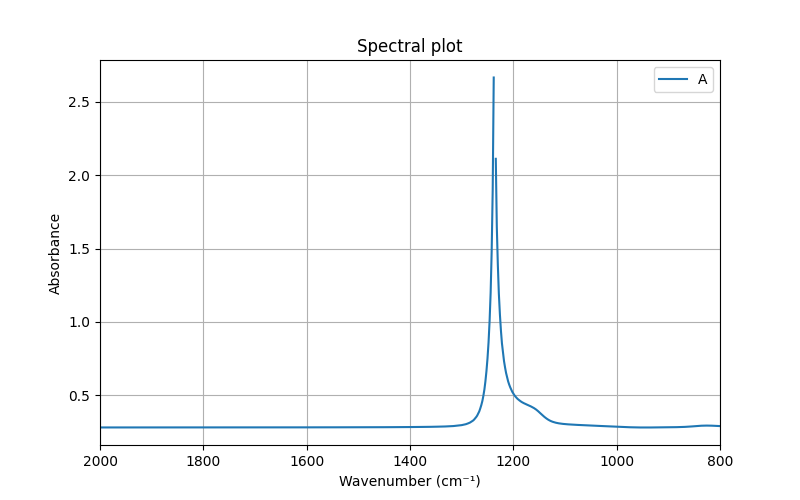

Processing sheet: 2.05


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


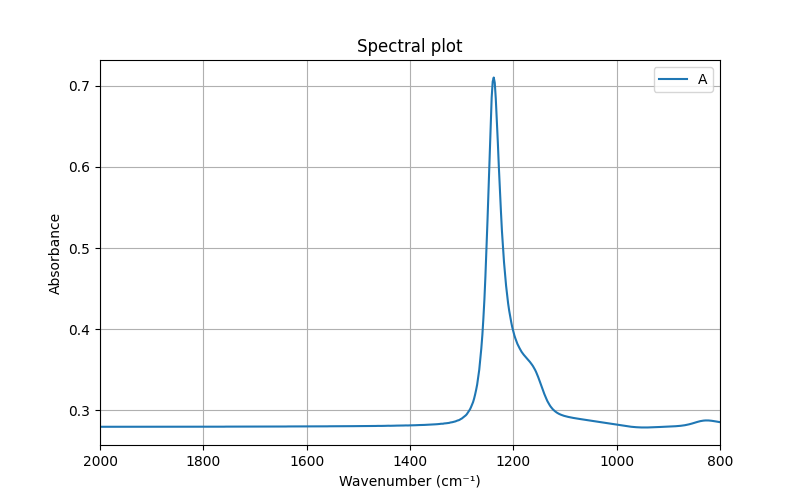

Processing sheet: 2.05 (2)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


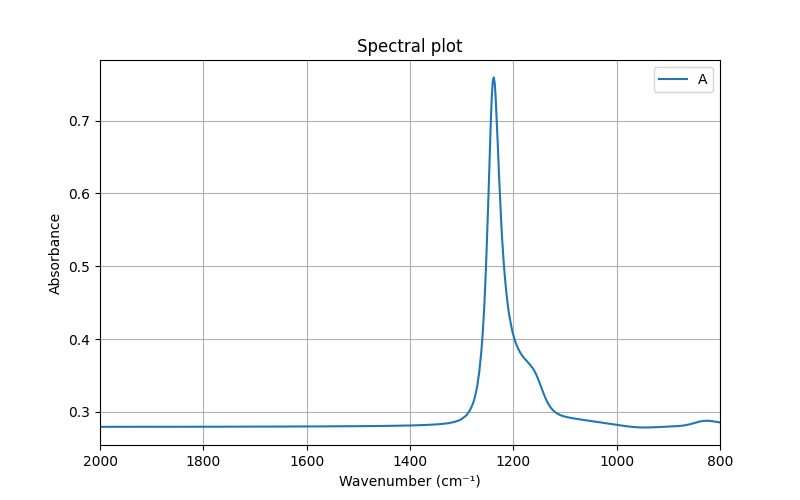

Processing sheet: 2.05 (3)


/tmp/ipykernel_440116/2097195245.py:50: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2097195245.py:42: RuntimeWarning: invalid value encountered in scalar divide
  sin_theta_t = (n_i / n_t) * sin_deg(theta_i_deg)
/tmp/ipykernel_440116/2851560706.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator
/tmp/ipykernel_440116/3517712436.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (1 / tp) * np.array([[1, rp], [rp, 1]])
/tmp/ipykernel_440116/3517712436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  phase = 1j * 2 * np.pi * d * n_t * cos_theta_t / wavelength
/tmp/ipykernel_440116/3517712436.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return 1 / M[0, 0]


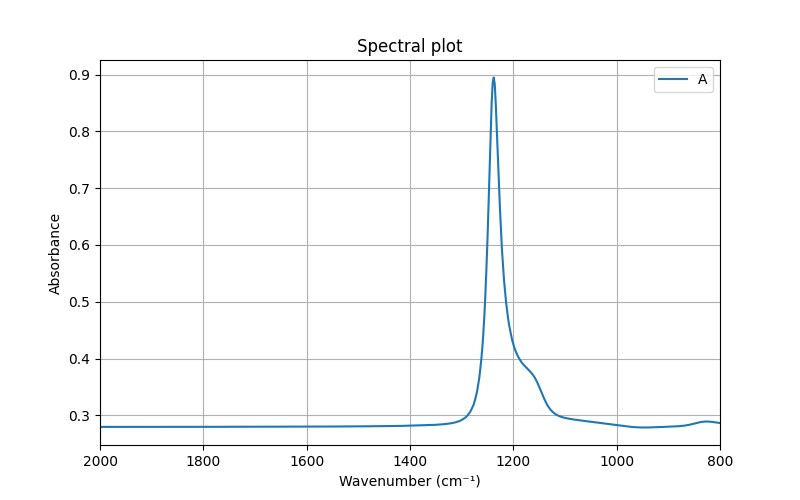

Finished processing all sheets.


In [50]:
input_file = f"{input('Enter excel workbook name: ')}.xlsx"
output_file = f"{input('Enter output workbook name: ')}.xlsx"

sheet_name = ["1.25","1.375","1.40","1.60","1.675","1.775","1.95","2.00","2.00 (2)","2.00 (3)","2.00 (4)","2.00 (5)",
              "2.00 (6)","2.00 (7)","2.00 (8)","2.05","2.05 (2)","2.05 (3)"]
angle = 80
mode_num = "7"
#d is in cm
thickness = [float(16.5e-9),float(26e-9),float(37e-9),float(46e-9),float(45e-9),float(47.5e-9),float(48e-9),
             float(49e-9),float(54e-9),float(58e-9),float(76e-9),float(85e-9),float(92e-9),float(98e-9),
             float(105.5e-9),float(65e-9),float(69e-9),float(78e-9)]

input_vary = dict(zip(sheet_name, thickness))

xls = pd.ExcelFile(input_file)

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    for sheet_name, thickness in input_vary.items():

        print(f"Processing sheet: {sheet_name}")
        
        df = pd.read_excel(input_file, sheet_name=sheet_name)

        wave_numbers = df["wave_numbers"].values
        n0_array = df["n0"].values
        k0_array = df["k0"].values
        n1_array = df["n1"].values
        k1_array = df["k1"].values
        n2_array = df["n2"].values
        k2_array = df["k2"].values

        result_df = Spectraplot(
            wave_numbers,
            n0_array, n1_array, n2_array,
            k0_array, k1_array, k2_array,
            d=thickness,
            th0=angle,
            mode=mode_num,
            polarization='p'
        )

        result_df.to_excel(writer, sheet_name=sheet_name, index=False)
    

print("Finished processing all sheets.")

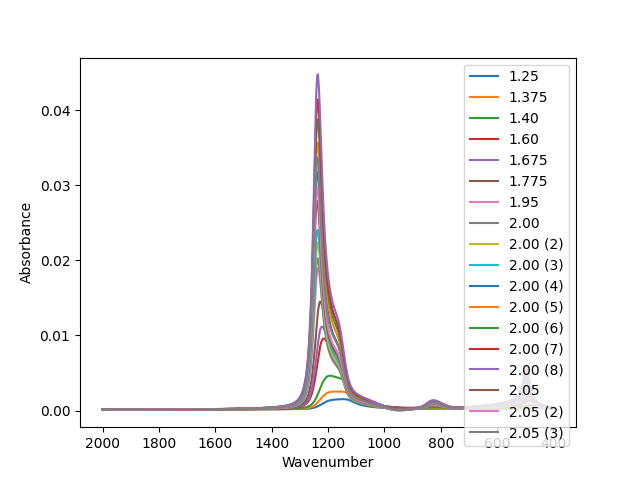

In [46]:
# Read the Excel file and plot all sheets with reversed x-axis
import pandas as pd
import matplotlib.pyplot as plt

file_path = "NEWspectest.xlsx"

# Load all sheets
xls = pd.ExcelFile(file_path)
sheets = xls.sheet_names

plt.figure()

for sheet in sheets:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    # Try to infer columns (assume first is wavenumber, second is absorbance)
    x = df.iloc[:, 0]
    y = df.iloc[:, 1]
    
    plt.plot(x, y, label=sheet)

plt.gca().invert_xaxis()  # reverse x-axis
plt.xlabel("Wavenumber")
plt.ylabel("Absorbance")
plt.legend()

plt.show()

In [47]:
# Combine all sheets into a single CSV (aligned by wavenumber)

import pandas as pd

file_path = "NEWspectest.xlsx"
output_path = "combined_spectra.csv"

xls = pd.ExcelFile(file_path)
sheets = xls.sheet_names

combined_df = None

for sheet in sheets:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    # Rename columns
    df = df.iloc[:, :2]
    df.columns = ["Wavenumber", sheet]
    
    if combined_df is None:
        combined_df = df
    else:
        combined_df = pd.merge(combined_df, df, on="Wavenumber", how="outer")

# Sort by wavenumber (descending to match reversed axis)
combined_df = combined_df.sort_values(by="Wavenumber", ascending=False)

# Save to CSV
combined_df.to_csv(output_path, index=False)

output_path

'combined_spectra.csv'